<a href="https://colab.research.google.com/github/Priya4740/Heart-disease-prediction-project/blob/main/Heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.calibration import calibration_curve, CalibratedClassifierCV


In [ ]:
!pip install -q shap joblib scikit-learn pandas numpy matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/ML-DL/Datasets/HeartDisease.csv')

In [ ]:
df

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,Male,Atypical angina,140,221,Lower than 120 mg/ml,ST-T wave abnormality,164,Yes,0.0,Downsloping,Zero,Fixed Defect,1
1021,60,Male,Typical angina,125,258,Lower than 120 mg/ml,Normal,141,Yes,2.8,Flat,One,Reversable Defect,0
1022,47,Male,Typical angina,110,275,Lower than 120 mg/ml,Normal,118,Yes,1.0,Flat,One,Fixed Defect,0
1023,50,Female,Typical angina,110,254,Lower than 120 mg/ml,Normal,159,No,0.0,Downsloping,Zero,Fixed Defect,1


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/ML-DL/Datasets/HeartDisease.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1025, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Rows: 1025
Columns: 14

Column Names:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia', 'target']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholestoral,0
fasting_blood_sugar,0
rest_ecg,0
Max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Missing Values:
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64

Duplicate Rows:
723


In [ ]:
print(df["target"].value_counts())

target
1    526
0    499
Name: count, dtype: int64


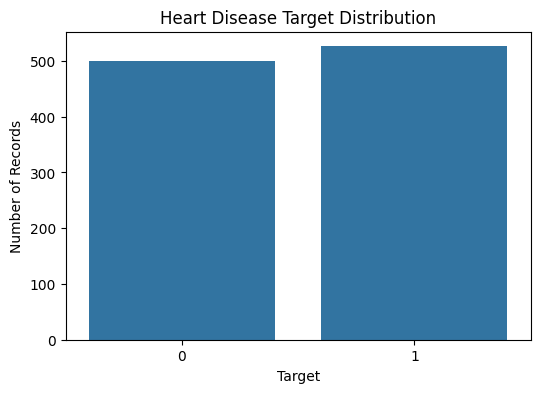

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x="target", data=df)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Records")
plt.show()

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (302, 14)


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholestoral,0
fasting_blood_sugar,0
rest_ecg,0
Max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


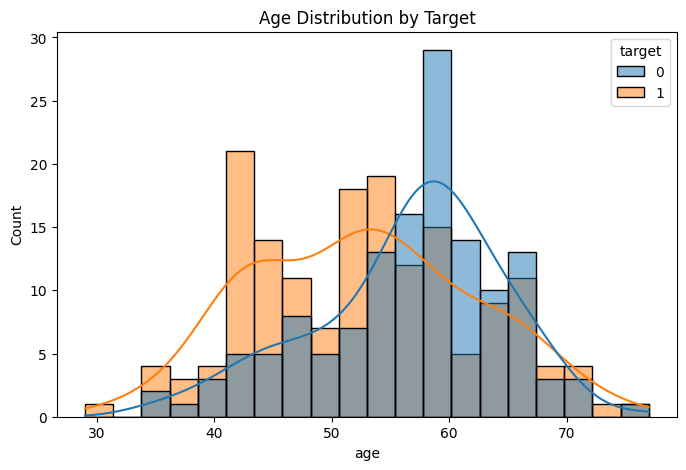

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    hue="target",
    kde=True,
    bins=20
)

plt.title("Age Distribution by Target")
plt.show()

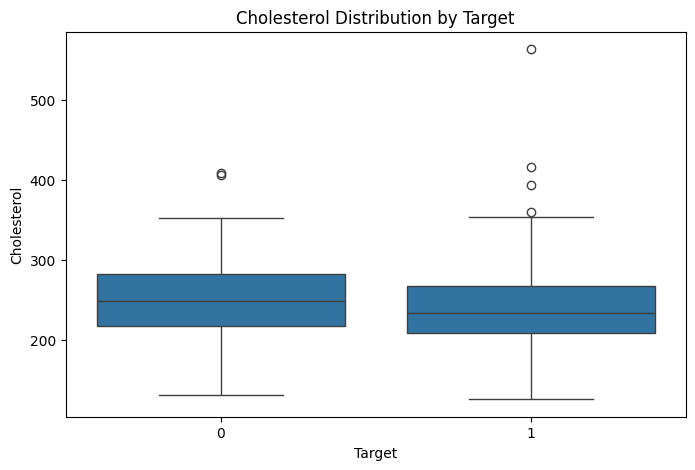

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="cholestoral"
)

plt.title("Cholesterol Distribution by Target")
plt.xlabel("Target")
plt.ylabel("Cholesterol")

plt.show()

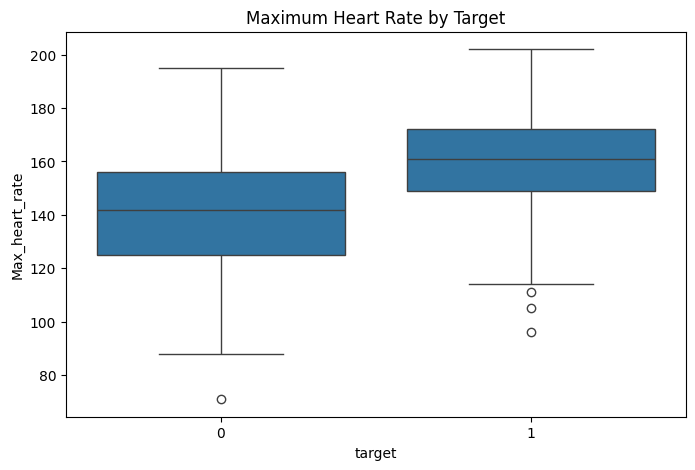

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="target",
    y="Max_heart_rate"
)

plt.title("Maximum Heart Rate by Target")
plt.show()

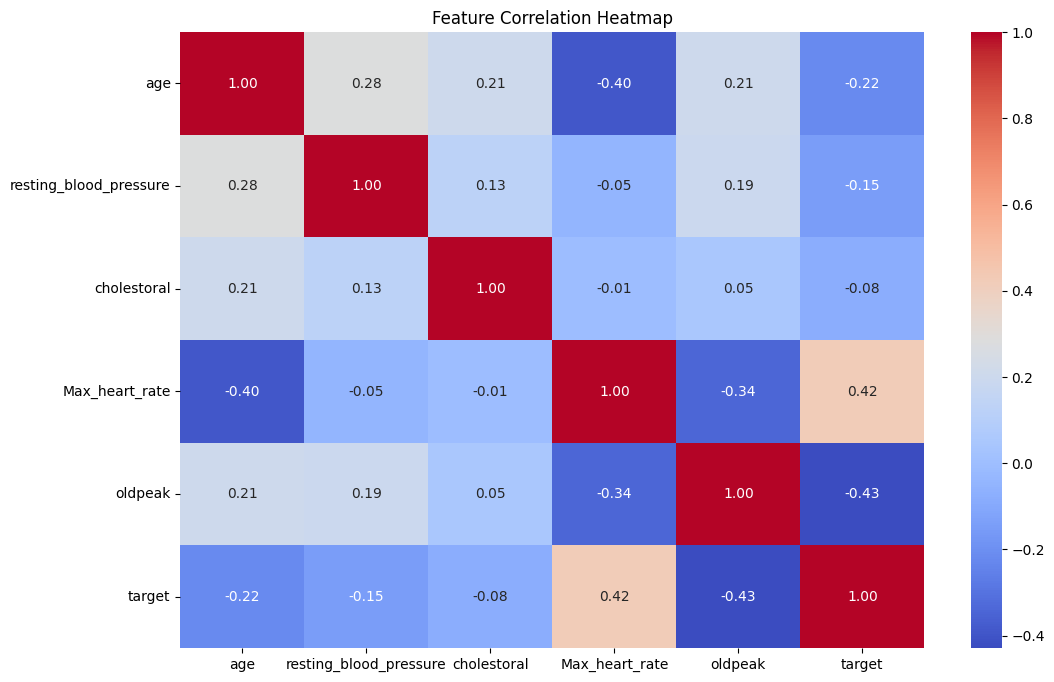

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']

Target:
target


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (241, 13)
Testing data: (61, 13)


In [ ]:
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True, random_state=42))
    ])
}

In [ ]:
categorical_cols = X_train.select_dtypes(include=['object']).columns

# Apply one-hot encoding to training data
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)

# Apply one-hot encoding to testing data and align columns with training data
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train_encoded, y_train)

    y_pred = model.predict(X_test_encoded)
    y_prob = model.predict_proba(X_test_encoded)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    })

    trained_models[name] = model

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.819672,0.805556,0.878788,0.840580,0.890693
4,SVM,0.770492,0.771429,0.818182,0.794118,0.869048
3,KNN,0.754098,0.736842,0.848485,0.788732,0.827922
2,Random Forest,0.754098,0.764706,0.787879,0.776119,0.869589
1,Decision Tree,0.754098,0.800000,0.727273,0.761905,0.756494


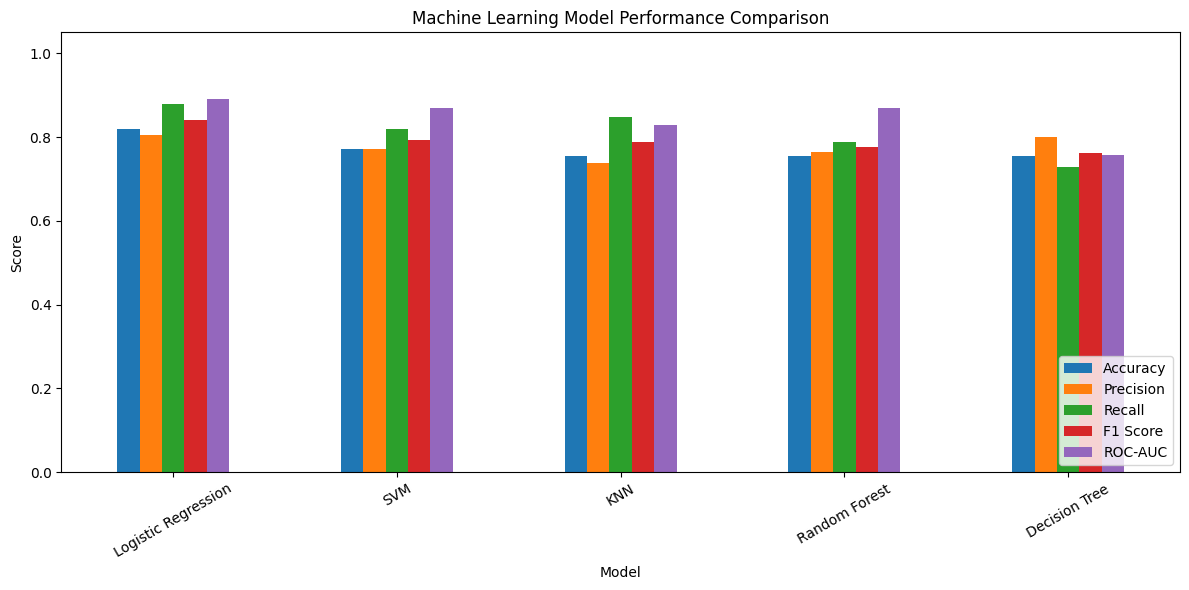

In [ ]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
for name, model in trained_models.items():

    print("=" * 60)
    print(name)

    y_pred = model.predict(X_test_encoded)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Class 0",
                "Class 1"
            ],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

     Class 0       0.84      0.75      0.79        28
     Class 1       0.81      0.88      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.81      0.82        61
weighted avg       0.82      0.82      0.82        61

Decision Tree
              precision    recall  f1-score   support

     Class 0       0.71      0.79      0.75        28
     Class 1       0.80      0.73      0.76        33

    accuracy                           0.75        61
   macro avg       0.75      0.76      0.75        61
weighted avg       0.76      0.75      0.75        61

Random Forest
              precision    recall  f1-score   support

     Class 0       0.74      0.71      0.73        28
     Class 1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75   

In [ ]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Logistic Regression


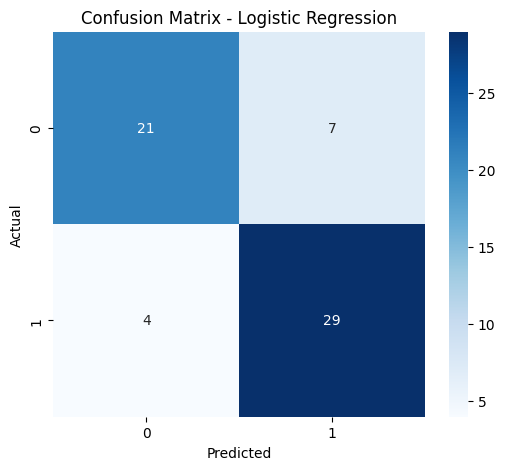

In [ ]:
y_pred_best = best_model.predict(X_test_encoded)


cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

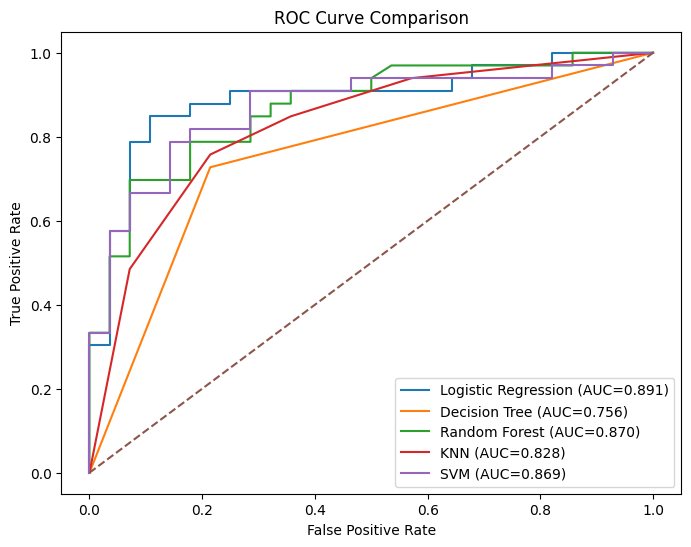

In [ ]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test_encoded)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

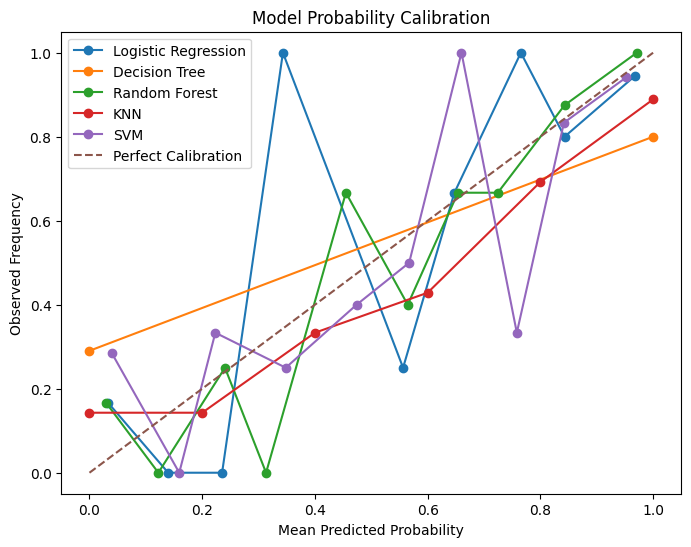

In [ ]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test_encoded)[:, 1]

    prob_true, prob_pred = calibration_curve(
        y_test,
        y_prob,
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")

plt.title("Model Probability Calibration")

plt.legend()
plt.show()

In [ ]:
rf_model = trained_models["Random Forest"]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_encoded)

In [ ]:
shap_values_output = explainer(X_test_encoded)

print(shap_values_output)

.values =
array([[[ 1.49690987e-02, -1.49690987e-02],
        [ 1.31780592e-02, -1.31780592e-02],
        [ 3.34131349e-02, -3.34131349e-02],
        ...,
        [-8.48187651e-04,  8.48187651e-04],
        [ 2.34891865e-03, -2.34891865e-03],
        [ 1.10800100e-01, -1.10800100e-01]],

       [[ 3.38274678e-02, -3.38274678e-02],
        [ 1.58344429e-02, -1.58344429e-02],
        [ 6.06725233e-02, -6.06725233e-02],
        ...,
        [-3.86607556e-04,  3.86607556e-04],
        [-3.55112908e-05,  3.55112908e-05],
        [ 7.24538057e-02, -7.24538057e-02]],

       [[-2.19432962e-03,  2.19432962e-03],
        [ 1.68272488e-03, -1.68272488e-03],
        [-1.33569528e-02,  1.33569528e-02],
        ...,
        [-2.92688221e-04,  2.92688221e-04],
        [ 1.48425677e-03, -1.48425677e-03],
        [ 7.69651507e-02, -7.69651507e-02]],

       ...,

       [[ 2.26044940e-02, -2.26044940e-02],
        [ 7.17007413e-05, -7.17007413e-05],
        [ 2.11016423e-02, -2.11016423e-02],
        

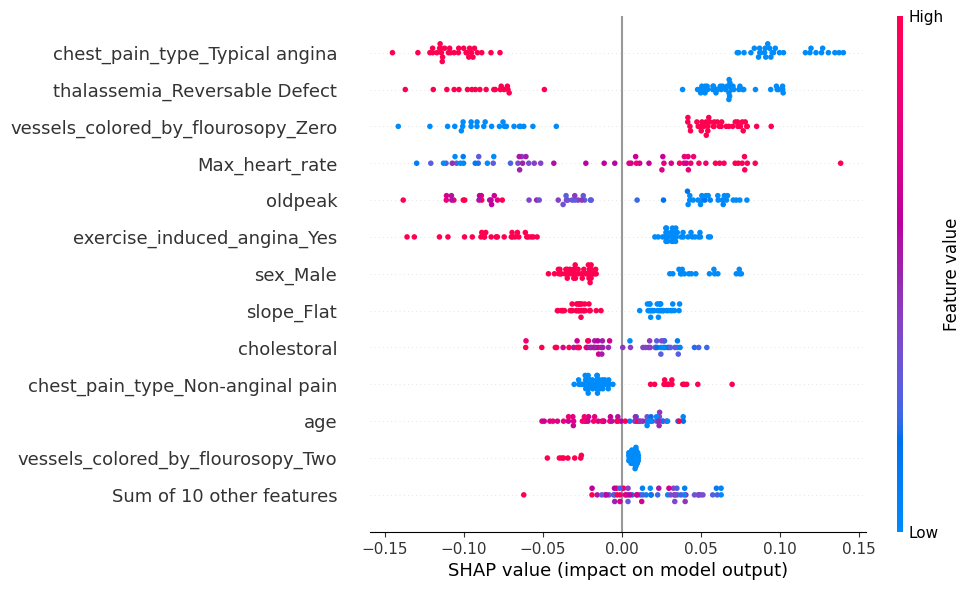

In [ ]:
shap.plots.beeswarm(
    shap_values_output[:, :, 1],
    max_display=13
)

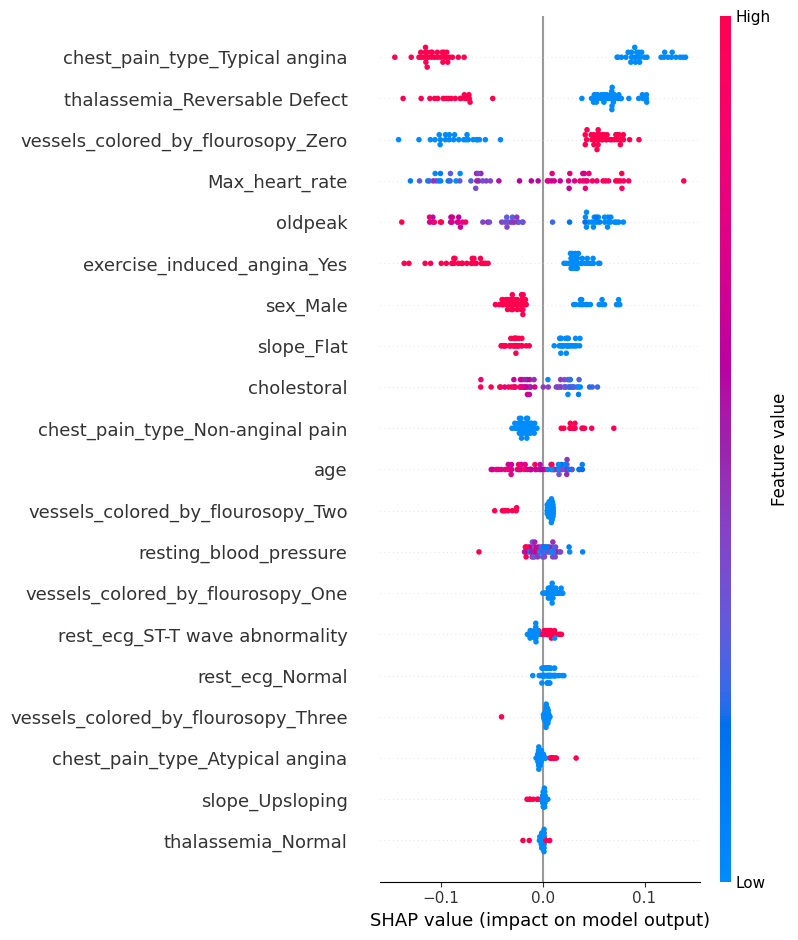

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_encoded,
    feature_names=X_test_encoded.columns
)

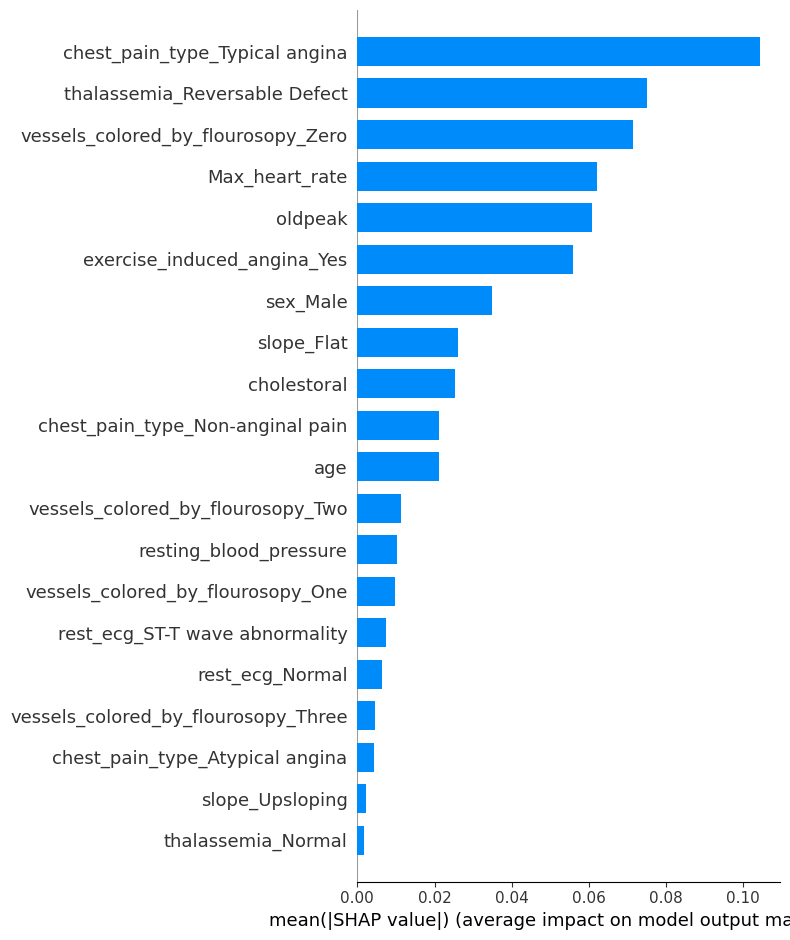

In [ ]:
shap.summary_plot(
    shap_values_output[:, :, 1],
    X_test_encoded,
    plot_type="bar"
)


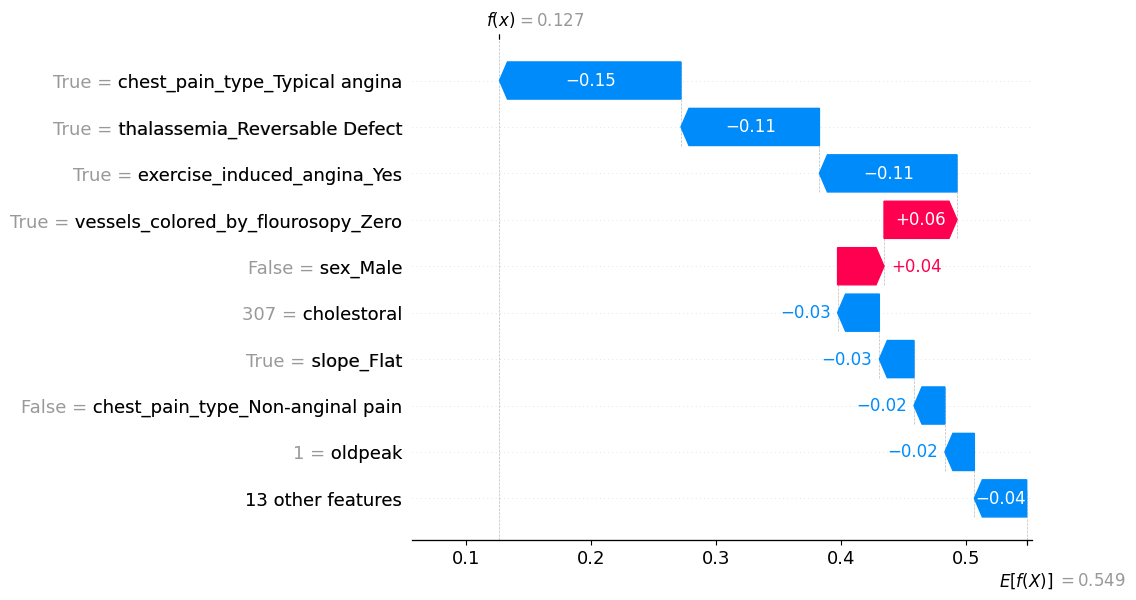

In [ ]:
sample_index = 0

shap.plots.waterfall(
    shap_values_output[sample_index, :, 1]
)

In [ ]:
joblib.dump(
    best_model,
    "heart_disease_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

print(feature_names)

['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']


In [ ]:
model_info = {
    "model_name": best_model_name,
    "features": feature_names,
    "metrics": results_df.to_dict(orient="records")
}

joblib.dump(
    model_info,
    "model_info.pkl"
)

print("Model information saved.")

Model information saved.


In [ ]:
loaded_model = joblib.load(
    "heart_disease_model.pkl"
)

sample = X_test_encoded.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

probability = loaded_model.predict_proba(sample)[0]

print("Prediction:", prediction)
print("Probabilities:", probability)

Prediction: 0
Probabilities: [0.78681241 0.21318759]


In [ ]:
def predict_heart_risk(input_data):
    # Convert the input list to a DataFrame with original feature names
    input_df = pd.DataFrame([input_data], columns=feature_names)

    # Identify categorical columns in the input DataFrame
    categorical_cols_in_input = input_df.select_dtypes(include=['object']).columns

    # Apply one-hot encoding, consistent with training data (drop_first=True)
    input_encoded = pd.get_dummies(input_df, columns=categorical_cols_in_input, drop_first=True)

    # Reindex to match the columns of the encoded training data (or X_test_encoded)
    # This ensures all expected features are present, with 0 for missing ones
    input_encoded = input_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

    # Make prediction and probability prediction using the best_model
    prediction = best_model.predict(input_encoded)[0]
    probabilities = best_model.predict_proba(input_encoded)[0]

    return prediction, probabilities

# Get a sample input from the test set
sample_input = X_test.iloc[0].tolist()

# Call the newly defined function
prediction, probabilities = predict_heart_risk(
    sample_input
)

print("Prediction:", prediction)
print("Class 0 probability:", probabilities[0])
print("Class 1 probability:", probabilities[1])

Prediction: 1
Class 0 probability: 0.013611476249355658
Class 1 probability: 0.9863885237506443


In [ ]:
import joblib

feature_names = joblib.load("feature_names.pkl")

print("Number of features:", len(feature_names))
print("Features:")
for feature in feature_names:
    print(feature)

Number of features: 13
Features:
age
sex
chest_pain_type
resting_blood_pressure
cholestoral
fasting_blood_sugar
rest_ecg
Max_heart_rate
exercise_induced_angina
oldpeak
slope
vessels_colored_by_flourosopy
thalassemia


In [ ]:
encoded_feature_names = X_train_encoded.columns.tolist()

joblib.dump(
    encoded_feature_names,
    "encoded_feature_names.pkl"
)

print("Encoded features:", encoded_feature_names)
print("Number of encoded features:", len(encoded_feature_names))

Encoded features: ['age', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate', 'oldpeak', 'sex_Male', 'chest_pain_type_Atypical angina', 'chest_pain_type_Non-anginal pain', 'chest_pain_type_Typical angina', 'fasting_blood_sugar_Lower than 120 mg/ml', 'rest_ecg_Normal', 'rest_ecg_ST-T wave abnormality', 'exercise_induced_angina_Yes', 'slope_Flat', 'slope_Upsloping', 'vessels_colored_by_flourosopy_One', 'vessels_colored_by_flourosopy_Three', 'vessels_colored_by_flourosopy_Two', 'vessels_colored_by_flourosopy_Zero', 'thalassemia_No', 'thalassemia_Normal', 'thalassemia_Reversable Defect']
Number of encoded features: 22


In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

joblib.dump(
    categorical_columns,
    "categorical_columns.pkl"
)

print("Categorical columns:", categorical_columns)

Categorical columns: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'rest_ecg', 'exercise_induced_angina', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']


In [ ]:
original_feature_names = X.columns.tolist()

joblib.dump(
    original_feature_names,
    "original_feature_names.pkl"
)

print("Original features:", original_feature_names)

Original features: ['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']


In [ ]:
encoded_feature_names = X_train_encoded.columns.tolist()

model_info = {
    "model_name": best_model_name,
    "original_features": original_feature_names,
    "encoded_features": encoded_feature_names,
    "categorical_columns": categorical_columns,
    "metrics": results_df.to_dict(orient="records")
}

joblib.dump(
    model_info,
    "model_info.pkl"
)

print("Model information saved successfully.")

Model information saved successfully.


In [ ]:
def prepare_input(input_data):

    input_df = pd.DataFrame(
        [input_data],
        columns=original_feature_names
    )

    input_encoded = pd.get_dummies(
        input_df,
        columns=categorical_columns,
        drop_first=True
    )

    input_encoded = input_encoded.reindex(
        columns=encoded_feature_names,
        fill_value=0
    )

    return input_encoded

In [ ]:
sample_input = X_test.iloc[0].to_dict()

prepared_sample = prepare_input(sample_input)

print("Prepared input shape:", prepared_sample.shape)

prediction = best_model.predict(prepared_sample)[0]
probability = best_model.predict_proba(prepared_sample)[0]

print("Prediction:", prediction)
print("Class 0 probability:", probability[0])
print("Class 1 probability:", probability[1])


Prepared input shape: (1, 22)
Prediction: 1
Class 0 probability: 0.013611476249355658
Class 1 probability: 0.9863885237506443


In [ ]:
print("X_train_encoded exists:", "X_train_encoded" in globals())

X_train_encoded exists: True


In [ ]:
encoded_feature_names = X_train_encoded.columns.tolist()

joblib.dump(
    encoded_feature_names,
    "encoded_feature_names.pkl"
)

print("Saved successfully!")
print(encoded_feature_names)

Saved successfully!
['age', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate', 'oldpeak', 'sex_Male', 'chest_pain_type_Atypical angina', 'chest_pain_type_Non-anginal pain', 'chest_pain_type_Typical angina', 'fasting_blood_sugar_Lower than 120 mg/ml', 'rest_ecg_Normal', 'rest_ecg_ST-T wave abnormality', 'exercise_induced_angina_Yes', 'slope_Flat', 'slope_Upsloping', 'vessels_colored_by_flourosopy_One', 'vessels_colored_by_flourosopy_Three', 'vessels_colored_by_flourosopy_Two', 'vessels_colored_by_flourosopy_Zero', 'thalassemia_No', 'thalassemia_Normal', 'thalassemia_Reversable Defect']
